# CNN-Based Speech Spectrogram Inpainting for Signal Loss Reconstruction

## Dataset preparation

In [1]:
from pathlib import Path
import pandas as pd
import wave

import librosa
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from IPython.display import Audio, display

import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torchmetrics.audio import ScaleInvariantSignalDistortionRatio

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
root = Path(r"\\NAS61E261\Datasets\Google Speech Commands")

In [4]:
val_list_path = root / "validation_list.txt"
test_list_path = root / "testing_list.txt"

In [5]:
def read_split_list(path: Path) -> set[str]:
    with open(path, "r", encoding="utf-8") as f:
        return {line.strip().replace("/", "\\") for line in f if line.strip()}

In [6]:
def wav_duration_ms(path: Path) -> float:
    with wave.open(str(path), "rb") as wf:
        frames = wf.getnframes()
        sr = wf.getframerate()
        return frames / sr * 1000.0

In [7]:
val_files = read_split_list(val_list_path)
test_files = read_split_list(test_list_path)

In [8]:
rows = []

In [8]:
for wav in sorted(root.rglob("*.wav")):
    if "_background_noise_" in wav.parts:
        continue

    rel = str(wav.relative_to(root))

    if rel in val_files:
        split = "validation"
    elif rel in test_files:
        split = "test"
    else:
        split = "train"

    duration_ms = wav_duration_ms(wav)

    # skip short recordings
    if duration_ms < 900:
        continue

    rows.append({
        "path": str(wav),
        "relative_path": rel,
        "label": wav.parent.name,
        "split": split,
        "duration_ms": round(duration_ms, 2),
        "padding_ms": round(1000.0 - duration_ms, 2),
    })

In [9]:
df = pd.DataFrame(rows)

In [12]:
# save to csv
out_path = root / "speech_commands_prepared.csv"
df.to_csv(out_path, index=False, encoding="utf-8")
print("\nSaved:", out_path)


Saved: \\NAS61E261\Datasets\Google Speech Commands\speech_commands_prepared.csv


In [13]:
summary = (
    df.groupby("split")
    .agg(
        count=("path", "count"),
        mean_duration_ms=("duration_ms", "mean"),
        min_duration_ms=("duration_ms", "min"),
        max_duration_ms=("duration_ms", "max"),
    )
    .reset_index()
)

summary["percent"] = (summary["count"] / len(df) * 100).round(2)

print(summary)
print("\nTotal:", len(df))

        split  count  mean_duration_ms  min_duration_ms  max_duration_ms  \
0        test   6483        998.447958           917.38           1000.0   
1       train  47759        998.321833           905.62           1000.0   
2  validation   6398        998.185358           928.81           1000.0   

   percent  
0    10.69  
1    78.76  
2    10.55  

Total: 60640


## Dataset preprocessing

In [9]:
prepared_index_path = root / "speech_commands_prepared.csv"
dataframe = pd.read_csv(prepared_index_path)

### Configuration

In [10]:
SAMPLE_RATE = 16000
TARGET_DURATION_MS = 1000
TARGET_NUM_SAMPLES = int(SAMPLE_RATE * (TARGET_DURATION_MS / 1000))

N_FFT = 512
WIN_LENGTH = 512
HOP_LENGTH = 160

HOP_MS = HOP_LENGTH / SAMPLE_RATE * 1000
STFT_WINDOW = torch.hann_window(N_FFT).to(device)

In [11]:
TRAIN_SEED = 47
VALIDATION_SEED = 42
TEST_SEED = 42

SPLIT_SEEDS = {
    "train": TRAIN_SEED,
    "validation": VALIDATION_SEED,
    "test": TEST_SEED,
}

In [12]:
SCENARIOS = {
    "20ms_x3": {
        "loss_width_frames": 2,
        "num_losses": 3,
    },
    "20ms_x5": {
        "loss_width_frames": 2,
        "num_losses": 5,
    },
    "60ms_x1": {
        "loss_width_frames": 6,
        "num_losses": 1,
    },
    "60ms_x2": {
        "loss_width_frames": 6,
        "num_losses": 2,
    },
    "60ms_x3": {
        "loss_width_frames": 6,
        "num_losses": 3,
    },
}

In [13]:
def load_fixed_length_audio(path: str) -> np.ndarray:
    audio, _ = librosa.load(
        path,
        sr=SAMPLE_RATE,
        mono=True,
    )

    audio = audio[:TARGET_NUM_SAMPLES]

    if len(audio) < TARGET_NUM_SAMPLES:
        audio = np.pad(
            audio,
            (0, TARGET_NUM_SAMPLES - len(audio)),
            mode="constant",
        )

    return audio.astype(np.float32)

In [14]:
def create_segmented_loss_mask(
    num_freq_bins: int,
    num_time_frames: int,
    valid_time_frames: int,
    loss_width_frames: int,
    num_losses: int,
    rng: np.random.Generator,
) -> np.ndarray:
    loss_mask = np.zeros(
        (num_freq_bins, num_time_frames),
        dtype=np.float32,
    )

    valid_time_frames = min(valid_time_frames, num_time_frames)

    if valid_time_frames < loss_width_frames:
        return loss_mask

    segment_edges = np.linspace(
        0,
        valid_time_frames,
        num_losses + 1,
        dtype=int,
    )

    for segment_index in range(num_losses):
        segment_start = segment_edges[segment_index]
        segment_end = segment_edges[segment_index + 1]

        max_start = segment_end - loss_width_frames

        if max_start < segment_start:
            continue

        start = int(rng.integers(segment_start, max_start + 1))
        end = start + loss_width_frames

        loss_mask[:, start:end] = 1.0

    return loss_mask

In [15]:
class SpeechSpectrogramInpaintingDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        split: str,
        scenario_name: str,
        split_seed: int = 42,
    ):
        if scenario_name not in SCENARIOS and scenario_name != "mixed":
            raise ValueError(f"Unknown scenario: {scenario_name}")

        self.dataframe = (
            dataframe
            .loc[dataframe["split"] == split]
            .reset_index(drop=True)
        )

        self.split = split
        self.scenario_name = scenario_name
        self.scenario = None
        if scenario_name != "mixed":
            self.scenario = SCENARIOS[scenario_name]
        self.split_seed = split_seed

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        audio = load_fixed_length_audio(row["path"])

        stft = librosa.stft(
            audio,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=WIN_LENGTH,
            window="hann",
        )

        magnitude = np.abs(stft)
        phase = np.angle(stft).astype(np.float32)

        target_mag = np.log1p(magnitude).astype(np.float32)

        num_freq_bins, num_time_frames = target_mag.shape

        valid_time_frames = int(row["duration_ms"] // HOP_MS)
        valid_time_frames = min(valid_time_frames, num_time_frames)

        rng = np.random.default_rng(self.split_seed + index)


        current_scenario = self.scenario
        if self.scenario_name == "mixed":
            scenario_names = list(SCENARIOS.keys())
            scenario_index = rng.integers(0, len(scenario_names))
            current_scenario = SCENARIOS[scenario_names[scenario_index]]
            
        loss_mask = create_segmented_loss_mask(
            num_freq_bins=num_freq_bins,
            num_time_frames=num_time_frames,
            valid_time_frames=valid_time_frames,
            loss_width_frames=current_scenario["loss_width_frames"],
            num_losses=current_scenario["num_losses"],
            rng=rng,
        )

        masked_mag = target_mag.copy()
        masked_mag[loss_mask == 1.0] = 0.0

        input_tensor = torch.from_numpy(
            np.stack(
                [
                    masked_mag,
                    loss_mask,
                ],
                axis=0,
            )
        )

        target_tensor = torch.from_numpy(
            target_mag[None, :, :]
        )

        return input_tensor, target_tensor, torch.from_numpy(phase)

In [16]:
scenario_name = "20ms_x5"

train_dataset = SpeechSpectrogramInpaintingDataset(
    dataframe=dataframe,
    split="train",
    scenario_name="mixed",
    split_seed=SPLIT_SEEDS["train"],
)

validation_dataset = SpeechSpectrogramInpaintingDataset(
    dataframe=dataframe,
    split="validation",
    scenario_name="mixed",
    split_seed=SPLIT_SEEDS["validation"],
)

test_dataset = SpeechSpectrogramInpaintingDataset(
    dataframe=dataframe,
    split="test",
    scenario_name=scenario_name,
    split_seed=SPLIT_SEEDS["test"],
)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

### Dataloader Testing

In [18]:
def log_magnitude_to_audio(log_magnitude, phase):
    magnitude = np.expm1(log_magnitude)

    complex_stft = magnitude * np.exp(1j * phase)

    audio = librosa.istft(
        complex_stft,
        hop_length=HOP_LENGTH,
        length=TARGET_NUM_SAMPLES,
    )

    return audio.astype(np.float32)

In [19]:
def show_batch_sample(batch, sample_index=0):
    inputs, targets, phases = batch

    masked_log_mag = inputs[sample_index, 0].cpu().numpy()
    loss_mask = inputs[sample_index, 1].cpu().numpy()
    target_log_mag = targets[sample_index, 0].cpu().numpy()
    phase = phases[sample_index].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(target_log_mag, origin="lower", aspect="auto")
    axes[0].set_title("Target log-magnitude")

    axes[1].imshow(masked_log_mag, origin="lower", aspect="auto")
    axes[1].set_title("Masked log-magnitude")

    axes[2].imshow(loss_mask, origin="lower", aspect="auto")
    axes[2].set_title("Loss mask")

    for ax in axes:
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Frequency bins")

    plt.tight_layout()
    plt.show()

    target_audio = log_magnitude_to_audio(target_log_mag, phase)
    masked_audio = log_magnitude_to_audio(masked_log_mag, phase)

    print("Target audio")
    display(Audio(target_audio, rate=SAMPLE_RATE))

    print("Masked audio")
    display(Audio(masked_audio, rate=SAMPLE_RATE))

Input shape: torch.Size([32, 2, 257, 101])
Target shape: torch.Size([32, 1, 257, 101])
Phase shape: torch.Size([32, 257, 101])


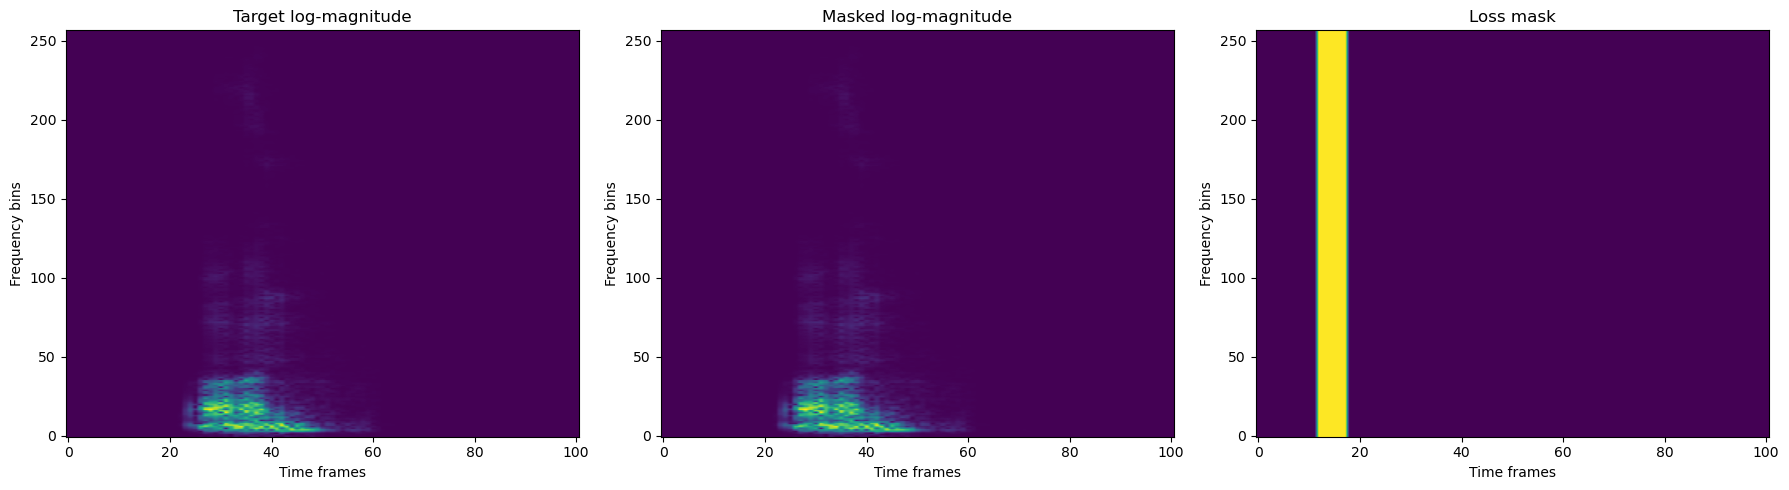

Target audio


Masked audio


In [20]:
batch = next(iter(train_loader))

print("Input shape:", batch[0].shape)
print("Target shape:", batch[1].shape)
print("Phase shape:", batch[2].shape)

show_batch_sample(batch, sample_index=10)

# Reconstruction U-Net architecture

In [21]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [22]:
class RecUNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        self.encoder_1 = ConvBlock(in_channels, 32)
        self.pool_1 = nn.MaxPool2d(kernel_size=2)

        self.encoder_2 = ConvBlock(32, 64)
        self.pool_2 = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = ConvBlock(64, 128)

        self.up_2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder_2 = ConvBlock(128, 64)

        self.up_1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder_1 = ConvBlock(64, 32)

        self.output_layer = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        enc_1 = self.encoder_1(x)
        x = self.pool_1(enc_1)

        enc_2 = self.encoder_2(x)
        x = self.pool_2(enc_2)

        x = self.bottleneck(x)

        x = self.up_2(x)
        x = self._match_size(x, enc_2)
        x = torch.cat([x, enc_2], dim=1)
        x = self.decoder_2(x)

        x = self.up_1(x)
        x = self._match_size(x, enc_1)
        x = torch.cat([x, enc_1], dim=1)
        x = self.decoder_1(x)

        return self.output_layer(x)

    @staticmethod
    def _match_size(x, reference):
        if x.shape[-2:] != reference.shape[-2:]:
            x = F.interpolate(
                x,
                size=reference.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )
        return x

# Training

In [23]:
model = RecUNet(
    in_channels=2,
    out_channels=1,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

NUM_EPOCHS = 30
GLOBAL_LOSS_WEIGHT = 0.1

In [24]:
def reconstruction_loss_v1(outputs, targets, inputs):
    loss_mask = inputs[:, 1:2, :, :]

    masked_l1 = F.l1_loss(
        outputs * loss_mask,
        targets * loss_mask,
    )

    global_l1 = F.l1_loss(
        outputs,
        targets,
    )

    loss = masked_l1 + GLOBAL_LOSS_WEIGHT * global_l1

    return loss, masked_l1, global_l1

In [25]:
def reconstruction_loss_v2(outputs, targets, inputs):
    loss_mask = inputs[:, 1:2, :, :]

    abs_error = torch.abs(outputs - targets)

    masked_l1 = (
        abs_error * loss_mask
    ).sum() / loss_mask.sum().clamp_min(1.0)

    global_l1 = abs_error.mean()

    loss = masked_l1 + 0.1 * global_l1

    return loss, masked_l1, global_l1

In [26]:
def reconstruction_loss(outputs, targets, inputs, global_weight=0.1):
    loss_mask = inputs[:, 1:2, :, :]

    abs_error = torch.abs(outputs - targets)
    squared_error = (outputs - targets) ** 2

    masked_l1 = (
        (abs_error * loss_mask).sum()
        / loss_mask.sum().clamp_min(1.0)
    )

    masked_mse = (
        (squared_error * loss_mask).sum()
        / loss_mask.sum().clamp_min(1.0)
    )

    global_l1 = abs_error.mean()

    global_mse = squared_error.mean()

    loss = masked_l1 + global_weight * global_l1

    return {
        "loss": loss,
        "masked_l1": masked_l1,
        "masked_mse": masked_mse,
        "global_l1": global_l1,
        "global_mse": global_mse,
    }

In [27]:
si_sdr_metric = ScaleInvariantSignalDistortionRatio().to(device)

In [28]:
def reconstruct_audio_batch(log_magnitude, phase):
    magnitude = torch.expm1(log_magnitude).clamp_min(0.0)

    complex_stft = torch.polar(magnitude.squeeze(1), phase)

    audio = torch.istft(
        complex_stft,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        window=STFT_WINDOW,
        length=TARGET_NUM_SAMPLES,
    )

    return audio

In [29]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device,
    si_sdr_metric,
):
    model.train()

    totals = {
        "loss": 0.0,
        "masked_l1": 0.0,
        "masked_mse": 0.0,
        "global_l1": 0.0,
        "global_mse": 0.0,
        "si_sdr": 0.0,
    }

    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc="Train",
        leave=True,
        ncols=180,
    )

    for batch_index, (inputs, targets, phases) in enumerate(progress_bar, start=1):
        inputs = inputs.to(device)
        targets = targets.to(device)
        phases = phases.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        metrics = reconstruction_loss(
            outputs,
            targets,
            inputs,
        )

        loss = metrics["loss"]

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            masked_log_mag = inputs[:, 0:1, :, :]
            loss_mask = inputs[:, 1:2, :, :]
    
            final_log_mag = (
                masked_log_mag * (1.0 - loss_mask)
                + outputs * loss_mask
            )
    
            target_audio = reconstruct_audio_batch(
                targets,
                phases,
            )
    
            reconstructed_audio = reconstruct_audio_batch(
                final_log_mag,
                phases,
            )
    
            si_sdr_value = si_sdr_metric(
                reconstructed_audio,
                target_audio,
            )
    
            batch_size = inputs.size(0)
            total_samples += batch_size
    
            for name, value in metrics.items():
                totals[name] += value.item() * batch_size
    
            totals["si_sdr"] += si_sdr_value.item() * batch_size
    
            progress_bar.set_postfix({
                "loss": f"{totals['loss'] / total_samples:.5f}",
                "m_l1": f"{totals['masked_l1'] / total_samples:.5f}",
                "g_l1": f"{totals['global_l1'] / total_samples:.5f}",
                "m_mse": f"{totals['masked_mse'] / total_samples:.5f}",
                "g_mse": f"{totals['global_mse'] / total_samples:.5f}",
                "si_sdr": f"{totals['si_sdr'] / total_samples:.2f}",
            })

    return {
        name: value / total_samples
        for name, value in totals.items()
    }

In [30]:
@torch.no_grad()
def evaluate(
    model,
    dataloader,
    device,
    si_sdr_metric,
    desc="Validation",
):
    model.eval()

    totals = {
        "loss": 0.0,
        "masked_l1": 0.0,
        "masked_mse": 0.0,
        "global_l1": 0.0,
        "global_mse": 0.0,
        "si_sdr": 0.0,
    }

    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=desc,
        leave=True,
        ncols=180,
    )

    for batch_index, (inputs, targets, phases) in enumerate(progress_bar, start=1):
        inputs = inputs.to(device)
        targets = targets.to(device)
        phases = phases.to(device)

        outputs = model(inputs)

        metrics = reconstruction_loss(
            outputs,
            targets,
            inputs,
        )

        masked_log_mag = inputs[:, 0:1, :, :]
        loss_mask = inputs[:, 1:2, :, :]

        final_log_mag = (
            masked_log_mag * (1.0 - loss_mask)
            + outputs * loss_mask
        )

        target_audio = reconstruct_audio_batch(
            targets,
            phases,
        )

        reconstructed_audio = reconstruct_audio_batch(
            final_log_mag,
            phases,
        )

        si_sdr_value = si_sdr_metric(
            reconstructed_audio,
            target_audio,
        )

        batch_size = inputs.size(0)
        total_samples += batch_size

        for name, value in metrics.items():
            totals[name] += value.item() * batch_size

        totals["si_sdr"] += si_sdr_value.item() * batch_size

        progress_bar.set_postfix({
            "loss": f"{totals['loss'] / total_samples:.5f}",
            "m_l1": f"{totals['masked_l1'] / total_samples:.5f}",
            "g_l1": f"{totals['global_l1'] / total_samples:.5f}",
            "m_mse": f"{totals['masked_mse'] / total_samples:.5f}",
            "g_mse": f"{totals['global_mse'] / total_samples:.5f}",
            "si_sdr": f"{totals['si_sdr'] / total_samples:.2f}",
        })

    return {
        name: value / total_samples
        for name, value in totals.items()
    }

In [40]:
best_validation_loss = float("inf")
best_model_path = "rec_unet_best.pt"

history_path = "training_history.csv"
history = []

In [36]:
for epoch in range(NUM_EPOCHS + 1, NUM_EPOCHS + 20 + 1):
    torch.cuda.empty_cache()
    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        si_sdr_metric=si_sdr_metric,
    )

    validation_metrics = evaluate(
        model=model,
        dataloader=validation_loader,
        device=device,
        si_sdr_metric=si_sdr_metric,
        desc="Validation",
    )

    row = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_masked_l1": train_metrics["masked_l1"],
        "train_masked_mse": train_metrics["masked_mse"],
        "train_global_l1": train_metrics["global_l1"],
        "train_global_mse": train_metrics["global_mse"],
        "train_si_sdr": train_metrics["si_sdr"],

        "validation_loss": validation_metrics["loss"],
        "validation_masked_l1": validation_metrics["masked_l1"],
        "validation_masked_mse": validation_metrics["masked_mse"],
        "validation_global_l1": validation_metrics["global_l1"],
        "validation_global_mse": validation_metrics["global_mse"],
        "validation_si_sdr": validation_metrics["si_sdr"],
    }

    history.append(row)

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss: {row['train_loss']:.5f} | "
        #f"train mL1: {row['train_masked_l1']:.5f} | "
        #f"train mMSE: {row['train_masked_mse']:.5f} | "
        f"train SI-SDR: {row['train_si_sdr']:.2f} | "
        f"val loss: {row['validation_loss']:.5f} | "
        #f"val mL1: {row['validation_masked_l1']:.5f} | "
        #f"val mMSE: {row['validation_masked_mse']:.5f} | "
        f"val SI-SDR: {row['validation_si_sdr']:.2f}"
    )

    if validation_metrics["loss"] < best_validation_loss:
        best_validation_loss = validation_metrics["loss"]

        torch.save(model.state_dict(), best_model_path)

        print(f"Saved best model: {best_model_path}")

Validation: 100%|███████████████████████████████████████████| 200/200 [03:02<00:00,  1.10it/s, loss=0.02331, m_l1=0.02289, g_l1=0.00426, m_mse=0.00598, g_mse=0.00066, si_sdr=30.58]


Epoch 031 | train loss: 0.02488 | train SI-SDR: 30.11 | val loss: 0.02331 | val SI-SDR: 30.58
Saved best model: rec_unet_best.pt


Validation: 100%|███████████████████████████████████████████| 200/200 [03:43<00:00,  1.12s/it, loss=0.02347, m_l1=0.02303, g_l1=0.00442, m_mse=0.00611, g_mse=0.00067, si_sdr=30.25]


Epoch 032 | train loss: 0.02475 | train SI-SDR: 30.17 | val loss: 0.02347 | val SI-SDR: 30.25


Validation: 100%|███████████████████████████████████████████| 200/200 [03:07<00:00,  1.07it/s, loss=0.02334, m_l1=0.02285, g_l1=0.00491, m_mse=0.00604, g_mse=0.00068, si_sdr=30.36]


...

Epoch 048 | train loss: 0.02398 | train SI-SDR: 30.52 | val loss: 0.02345 | val SI-SDR: 30.51


Validation: 100%|███████████████████████████████████████████| 200/200 [03:52<00:00,  1.16s/it, loss=0.02335, m_l1=0.02296, g_l1=0.00396, m_mse=0.00624, g_mse=0.00067, si_sdr=30.22]


Epoch 049 | train loss: 0.02395 | train SI-SDR: 30.53 | val loss: 0.02335 | val SI-SDR: 30.22


Validation: 100%|███████████████████████████████████████████| 200/200 [03:18<00:00,  1.01it/s, loss=0.02349, m_l1=0.02300, g_l1=0.00490, m_mse=0.00629, g_mse=0.00076, si_sdr=30.26]


Epoch 050 | train loss: 0.02393 | train SI-SDR: 30.55 | val loss: 0.02349 | val SI-SDR: 30.26


In [41]:
torch.cuda.empty_cache()

In [55]:
fin_model_path = "30ep/rec_unet_fin.pt"
torch.save(model.state_dict(), fin_model_path)

## Evaluation

In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import librosa

from torch.utils.data import Dataset, DataLoader
from torchmetrics.audio import ScaleInvariantSignalDistortionRatio
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

from pathlib import Path

In [32]:
def interpolate_masked_columns(masked_log_mag, loss_mask):
    restored = masked_log_mag.copy()

    num_freq_bins, num_time_frames = restored.shape

    masked_columns = np.where(loss_mask[0] > 0)[0]

    for col in masked_columns:
        left = col - 1

        while left >= 0 and loss_mask[0, left] > 0:
            left -= 1

        right = col + 1

        while right < num_time_frames and loss_mask[0, right] > 0:
            right += 1

        if left >= 0 and right < num_time_frames:
            alpha = (col - left) / (right - left)

            restored[:, col] = (
                (1.0 - alpha) * restored[:, left]
                + alpha * restored[:, right]
            )

        elif left >= 0:
            restored[:, col] = restored[:, left]

        elif right < num_time_frames:
            restored[:, col] = restored[:, right]

    return restored

In [33]:
def final_reconstruction(masked_log_mag, predicted_log_mag, loss_mask):
    return (
        masked_log_mag * (1.0 - loss_mask)
        + predicted_log_mag * loss_mask
    )

In [34]:
def masked_l1_np(predicted, target, mask):
    error = np.abs(predicted - target) * mask
    return error.sum() / max(mask.sum(), 1.0)


def masked_mse_np(predicted, target, mask):
    error = ((predicted - target) ** 2) * mask
    return error.sum() / max(mask.sum(), 1.0)


def masked_psnr_np(predicted, target, mask, eps=1e-8):
    mse = masked_mse_np(predicted, target, mask)

    max_value = target.max()
    if max_value <= eps:
        max_value = 1.0

    psnr = 10.0 * np.log10((max_value ** 2) / max(mse, eps))

    return psnr


def ssim_np(predicted, target):
    data_range = target.max() - target.min()

    if data_range <= 1e-12:
        return 1.0

    return ssim(
        target,
        predicted,
        data_range=data_range,
    )

In [35]:
def evaluate_interpolation_and_model(
    model,
    dataloader,
    device,
    si_sdr_metric,
    desc,
):
    model.eval()

    totals = {
        "interp_l1": 0.0,
        "interp_mse": 0.0,
        "interp_psnr": 0.0,
        "interp_ssim": 0.0,
        "interp_si_sdr": 0.0,

        "model_l1": 0.0,
        "model_mse": 0.0,
        "model_psnr": 0.0,
        "model_ssim": 0.0,
        "model_si_sdr": 0.0,
    }

    total_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=desc,
        leave=True,
        ncols=180,
    )

    with torch.no_grad():
        for inputs, targets, phases in progress_bar:
            inputs = inputs.to(device)
            targets = targets.to(device)
            phases = phases.to(device)

            outputs = model(inputs)

            masked_log_mag_batch = inputs[:, 0:1, :, :]
            loss_mask_batch = inputs[:, 1:2, :, :]

            model_final_log_mag = final_reconstruction(
                masked_log_mag_batch,
                outputs,
                loss_mask_batch,
            )

            target_audio = reconstruct_audio_batch(
                targets,
                phases,
            )

            model_audio = reconstruct_audio_batch(
                model_final_log_mag,
                phases,
            )

            model_si_sdr = si_sdr_metric(
                model_audio,
                target_audio,
            ).item()

            batch_size = inputs.size(0)

            interp_si_sdr_values = []

            for sample_index in range(batch_size):
                masked_log_mag = (
                    masked_log_mag_batch[sample_index, 0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                loss_mask = (
                    loss_mask_batch[sample_index, 0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                target_log_mag = (
                    targets[sample_index, 0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                model_log_mag = (
                    model_final_log_mag[sample_index, 0]
                    .detach()
                    .cpu()
                    .numpy()
                )

                interpolated_log_mag = interpolate_masked_columns(
                    masked_log_mag,
                    loss_mask,
                )

                totals["interp_l1"] += masked_l1_np(
                    interpolated_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["interp_mse"] += masked_mse_np(
                    interpolated_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["interp_psnr"] += masked_psnr_np(
                    interpolated_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["interp_ssim"] += ssim_np(
                    interpolated_log_mag,
                    target_log_mag,
                )

                totals["model_l1"] += masked_l1_np(
                    model_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["model_mse"] += masked_mse_np(
                    model_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["model_psnr"] += masked_psnr_np(
                    model_log_mag,
                    target_log_mag,
                    loss_mask,
                )

                totals["model_ssim"] += ssim_np(
                    model_log_mag,
                    target_log_mag,
                )

                interpolated_tensor = torch.from_numpy(
                    interpolated_log_mag[None, None, :, :]
                ).to(device)

                interpolated_audio = reconstruct_audio_batch(
                    interpolated_tensor,
                    phases[sample_index:sample_index + 1],
                )

                interp_si_sdr = si_sdr_metric(
                    interpolated_audio,
                    target_audio[sample_index:sample_index + 1],
                ).item()

                interp_si_sdr_values.append(interp_si_sdr)

            totals["interp_si_sdr"] += sum(interp_si_sdr_values)
            totals["model_si_sdr"] += model_si_sdr * batch_size

            total_samples += batch_size

            progress_bar.set_postfix({
                "N": total_samples,
                "interp_SI": f"{totals['interp_si_sdr'] / total_samples:.2f}",
                "model_SI": f"{totals['model_si_sdr'] / total_samples:.2f}",
            })

    return {
        name: value / total_samples
        for name, value in totals.items()
    }

In [36]:
model_path = "rec_unet_fin.pt"

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.to(device)

si_sdr_metric = ScaleInvariantSignalDistortionRatio().to(device)

C:\Users\Orest\AppData\Local\Temp\ipykernel_18044\2957040395.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=device)


In [37]:
test_loaders = {}

for scenario_name in SCENARIOS:
    test_dataset = SpeechSpectrogramInpaintingDataset(
        dataframe=dataframe,
        split="test",
        scenario_name=scenario_name,
        split_seed=SPLIT_SEEDS["test"],
    )

    test_loaders[scenario_name] = DataLoader(
        test_dataset,
        batch_size=23,
        shuffle=False,
        num_workers=0,
    )

In [63]:
results_rows = []

for scenario_name, test_loader in test_loaders.items():
    metrics = evaluate_interpolation_and_model(
        model=model,
        dataloader=test_loader,
        device=device,
        si_sdr_metric=si_sdr_metric,
        desc=f"Test [{scenario_name}]",
    )

    results_rows.append({
        "scenario": scenario_name,
        **metrics,
    })

results_df = pd.DataFrame(results_rows)

results_df.to_csv(
    "test_interpolation_vs_model_by_scenario.csv",
    index=False,
)

results_df

Test s_x3]: 100%|████████████████████████████████████████████████████████████████████████████████████| 282/282 [02:55<00:00,  1.60it/s, N=6483, interp_SI=19.15, model_SI=21.83]


,scenario,interp_l1,interp_mse,interp_psnr,interp_ssim,interp_si_sdr,model_l1,model_mse,model_psnr,model_ssim,model_si_sdr
0,20ms_x3,0.027424,0.007164,34.539065,0.995675,29.999001,0.019896,0.003888,37.434580,0.997489,33.627701
1,20ms_x5,0.027276,0.007165,33.097142,0.992816,24.949442,0.019818,0.003891,35.950514,0.995816,28.843720
2,60ms_x1,0.039385,0.014644,38.665307,0.992092,35.659504,0.029801,0.009446,40.799792,0.994666,37.693734
3,60ms_x2,0.038098,0.014101,33.007547,0.984501,24.702392,0.028684,0.009051,35.391691,0.989542,27.216854
4,60ms_x3,0.038513,0.014352,30.826374,0.976585,19.154576,0.029166,0.009297,33.130244,0.984181,21.830147


In [38]:
def calculate_sample_metrics(predicted_log_mag, target_log_mag, loss_mask, predicted_audio, target_audio):
    l1 = masked_l1_np(predicted_log_mag, target_log_mag, loss_mask)
    mse = masked_mse_np(predicted_log_mag, target_log_mag, loss_mask)
    psnr = masked_psnr_np(predicted_log_mag, target_log_mag, loss_mask)
    ssim_value = ssim_np(predicted_log_mag, target_log_mag)

    si_sdr_value = si_sdr_metric(
        torch.from_numpy(predicted_audio)[None, :].to(device),
        torch.from_numpy(target_audio)[None, :].to(device),
    ).item()

    return {
        "L1": l1,
        "MSE": mse,
        "PSNR": psnr,
        "SSIM": ssim_value,
        "SI-SDR": si_sdr_value,
    }


def print_sample_metrics(title, metrics):
    print(title)
    print(
        f"L1: {metrics['L1']:.5f} | "
        f"MSE: {metrics['MSE']:.5f} | "
        f"PSNR: {metrics['PSNR']:.2f} | "
        f"SSIM: {metrics['SSIM']:.4f} | "
        f"SI-SDR: {metrics['SI-SDR']:.2f}"
    )

In [39]:
def show_reconstruction_comparison(model, batch, sample_index=0, device=device):
    model.eval()

    inputs, targets, phases = batch

    input_sample = inputs[sample_index:sample_index + 1].to(device)
    target_sample = targets[sample_index:sample_index + 1].to(device)
    phase_sample = phases[sample_index:sample_index + 1].to(device)

    with torch.no_grad():
        output_sample = model(input_sample)

    masked_log_mag = input_sample[:, 0:1, :, :]
    loss_mask = input_sample[:, 1:2, :, :]

    model_final_log_mag = (
        masked_log_mag * (1.0 - loss_mask)
        + output_sample * loss_mask
    )

    masked_np = masked_log_mag[0, 0].detach().cpu().numpy()
    target_np = target_sample[0, 0].detach().cpu().numpy()
    mask_np = loss_mask[0, 0].detach().cpu().numpy()
    model_np = model_final_log_mag[0, 0].detach().cpu().numpy()

    interpolation_np = interpolate_masked_columns(
        masked_np,
        mask_np,
    )

    fig, axes = plt.subplots(1, 5, figsize=(26, 5))

    images = [
        (target_np, "Target"),
        (masked_np, "Masked"),
        (interpolation_np, "Linear interpolation"),
        (model_np, "U-Net reconstruction"),
        (mask_np, "Loss mask"),
    ]

    for ax, (image, title) in zip(axes, images):
        ax.imshow(
            image,
            origin="lower",
            aspect="auto",
        )
        ax.set_title(title)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Frequency bins")

    plt.tight_layout()
    plt.show()

    target_audio = reconstruct_audio_batch(
        target_sample,
        phase_sample,
    )[0].detach().cpu().numpy()

    masked_audio = reconstruct_audio_batch(
        masked_log_mag,
        phase_sample,
    )[0].detach().cpu().numpy()

    interpolation_tensor = torch.from_numpy(
        interpolation_np[None, None, :, :]
    ).float().to(device)

    interpolation_audio = reconstruct_audio_batch(
        interpolation_tensor,
        phase_sample,
    )[0].detach().cpu().numpy()

    model_audio = reconstruct_audio_batch(
        model_final_log_mag,
        phase_sample,
    )[0].detach().cpu().numpy()

    masked_metrics = calculate_sample_metrics(
        predicted_log_mag=masked_np,
        target_log_mag=target_np,
        loss_mask=mask_np,
        predicted_audio=masked_audio,
        target_audio=target_audio,
    )
    
    interpolation_metrics = calculate_sample_metrics(
        predicted_log_mag=interpolation_np,
        target_log_mag=target_np,
        loss_mask=mask_np,
        predicted_audio=interpolation_audio,
        target_audio=target_audio,
    )
    
    model_metrics = calculate_sample_metrics(
        predicted_log_mag=model_np,
        target_log_mag=target_np,
        loss_mask=mask_np,
        predicted_audio=model_audio,
        target_audio=target_audio,
    )

    print("Target audio")
    display(Audio(target_audio, rate=SAMPLE_RATE))

    print("Masked audio")
    print_sample_metrics("Masked", masked_metrics)
    display(Audio(masked_audio, rate=SAMPLE_RATE))

    print("Linear interpolation audio")
    print_sample_metrics("Linear interpolation", interpolation_metrics)
    display(Audio(interpolation_audio, rate=SAMPLE_RATE))

    print("U-Net reconstruction audio")
    print_sample_metrics("U-Net reconstruction", model_metrics)
    

    display(Audio(model_audio, rate=SAMPLE_RATE))

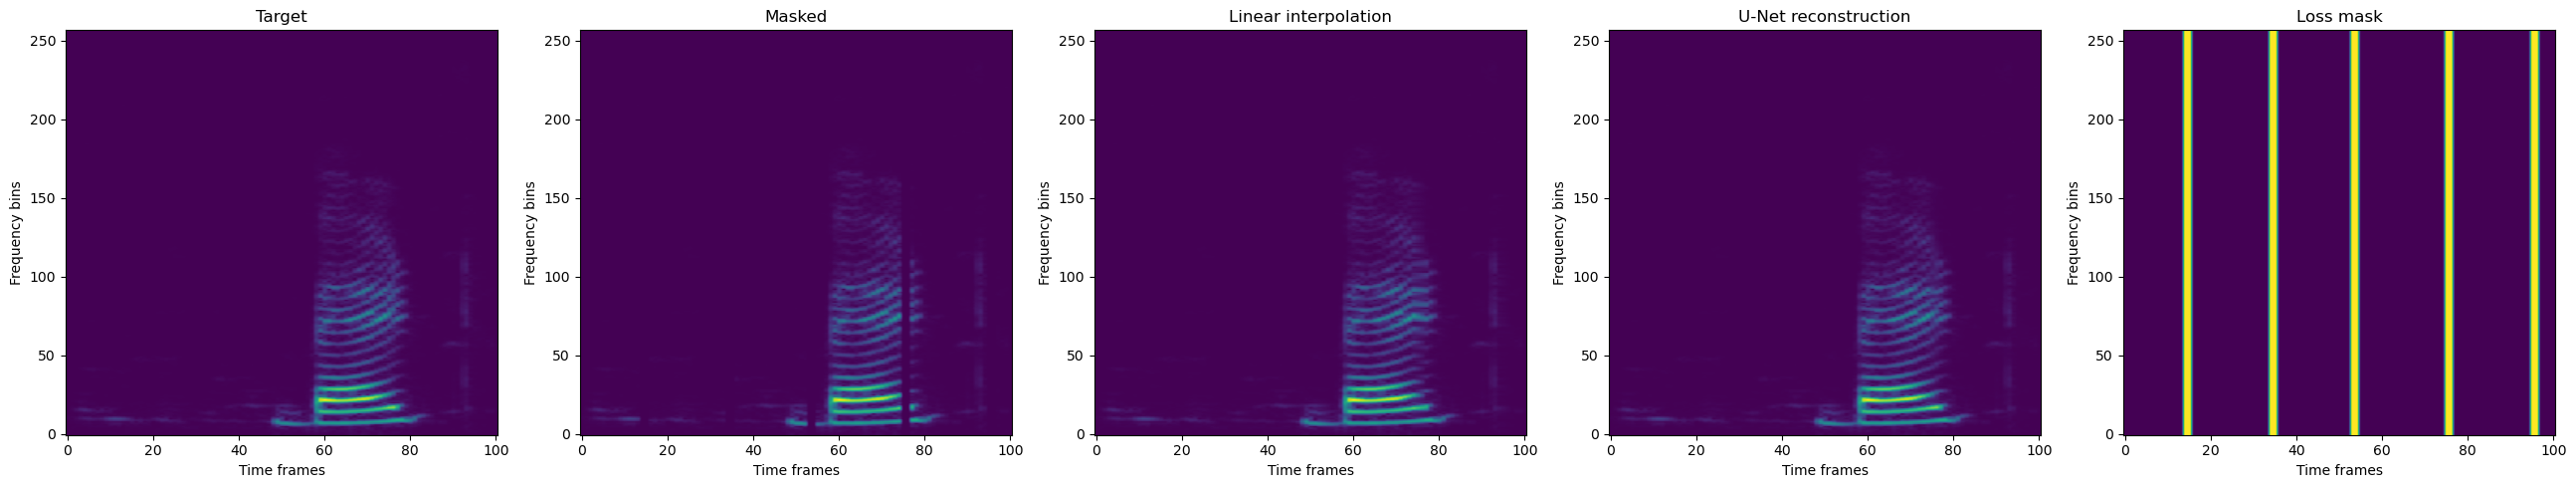

Target audio


Masked audio
Masked
L1: 0.05579 | MSE: 0.04474 | PSNR: 23.88 | SSIM: 0.9796 | SI-SDR: 12.85


Linear interpolation audio
Linear interpolation
L1: 0.02507 | MSE: 0.00791 | PSNR: 31.41 | SSIM: 0.9933 | SI-SDR: 20.80


U-Net reconstruction audio
U-Net reconstruction
L1: 0.01299 | MSE: 0.00208 | PSNR: 37.22 | SSIM: 0.9979 | SI-SDR: 31.21


In [45]:
batch = next(iter(test_loader))

show_reconstruction_comparison(
    model=model,
    batch=batch,
    sample_index=8,
    device=device,
)